## Compare all models
Compare the constraining power of different volumes of data on the model parameters.

In [24]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import os
from os.path import join
import json
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
mpl.style.use('../../style.mcstyle')   # noqa
import numpy as np
import torch
import seaborn as sns
import pandas as pd
import warnings
from tqdm import tqdm

from tools import torch_device

device = torch_device()

# Suppress warnings
warnings.filterwarnings('ignore')

Duplicate key in file '../../style.mcstyle', line 16 ('font.family: serif')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
CUDA is not available. Using CPU.


## Load a model

In [25]:
wdir = '/anvil/scratch/x-mho1/cmass-ili'

cosmonames = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', r'$n_s$', r'$\sigma_8$']
hodnames = [r'$\alpha$', r'$\log M_0$', r'$\log M_1$',
            r'$\log M_{\min}$', r'$\sigma_{\log M}$']
names = cosmonames  # +hodnames

# # Specify model configuration
# nbody = 'mtnglike'
# sim = 'fastpm_hodzbias'
# save_dir = join(wdir, nbody, sim, 'models')

# Specify data dtype
# tracer = 'halo'
tracer = 'galaxy'
summaries = ['nbar', 'zPk0', 'zPk2', 'zPk4']  # ,  'zQk0']
# summaries = ['Pk0', 'Pk2', 'Pk4', 'Qk0']
summary = '+'.join(summaries)
kmin, kmax = 0.0, 0.4
# modelpath = join(save_dir, tracer, summary, f'kmin-{kmin}_kmax-{kmax}')
# print(
#     f'Loading model: nbody={nbody}, sim={sim}, tracer={tracer}, \n\tsummary={summary}, kmin={kmin}, kmax={kmax}')
# print('\n'.join(os.listdir(modelpath)))

In [ ]:
suites = ['quijotelike', 'abacuslike', 'mtnglike']
# summlist = [
#     ['nbar', 'zPk0'],
#     ['nbar', 'zPk0', 'zPk2', 'zPk4'],
#     ['nbar', 'zPk0', 'zPk2', 'zPk4', 'zEqQk0'],
#     ['nbar', 'zPk0', 'zPk2', 'zPk4', 'zQk0']
# ]
summlist = [
    ['nbar', 'Pk0'],
    ['nbar', 'Pk0', 'Pk2', 'Pk4'],
    ['nbar', 'Pk0', 'Pk2', 'Pk4', 'EqQk0'],
    ['nbar', 'Pk0', 'Pk2', 'Pk4', 'Qk0']
]
summarylist = ['+'.join(s) for s in summlist]


# boxvols = (np.array([1, 2, 3]))**3  # for boxes
# vols = boxvols  # for galaxy boxes

# for survey footprints [APPROXIMATE TODO: CALCULATE]
boxvols = (np.array([2000, 2750, 3500])/1e3)**3  # for diagnostics
vols = np.array([0.4*2.9, 2.9, 7.9])*(0.7**3)

xtestdict, ytestdict, sampsdict, percsdict = {}, {}, {}, {}
for j, summary in enumerate(summarylist):
    xtests, ytests, sampss, percss = [], [], [], []
    for i, s in enumerate(suites):
        # Specify model configuration
        nbody = s
        sim = 'fastpm_recnoise'  # if s == 'quijotelike' else 'fastpm_hodzbias'
        if nbody == 'quijotelike':
            tracer = 'simbig_lightcone'
        elif nbody == 'abacuslike':
            tracer = 'sgc_lightcone'
        elif nbody == 'mtnglike':
            tracer = 'ngc_lightcone'
        save_dir = join(wdir, nbody, sim, 'models')
        modelpath = join(save_dir, tracer, summary, f'kmin-{kmin}_kmax-{kmax}')

        # Load predictions
        xtest = np.load(join(modelpath, 'x_test.npy'))
        ytest = np.load(join(modelpath, 'theta_test.npy'))
        samps = np.load(join(modelpath, 'posterior_samples.npy'))
        percs = np.percentile(samps, [16, 50, 84], axis=0)
        xtests.append(xtest), ytests.append(ytest)
        sampss.append(samps), percss.append(percs)
    xtestdict[summary] = xtests
    ytestdict[summary] = ytests
    sampsdict[summary] = sampss
    percsdict[summary] = percss

yrange = np.stack([
    ytest.min(axis=0),
    ytest.max(axis=0)
], axis=1)

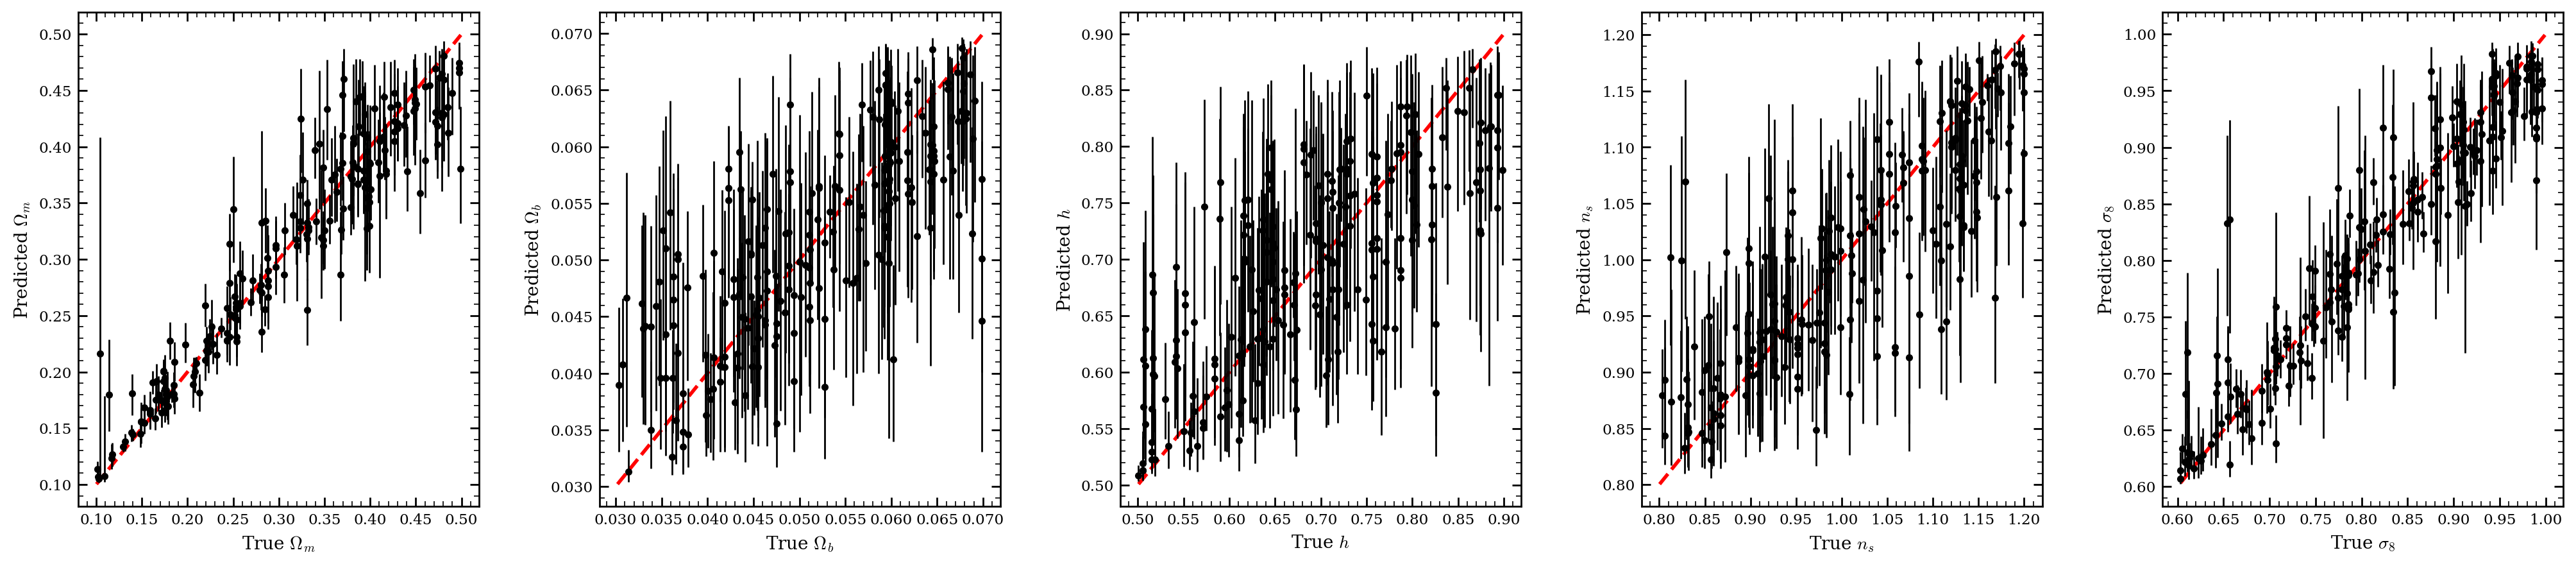

In [ ]:
ss = 10

N = len(names)
H, W = N//5, 5
f, axs = plt.subplots(H, W, figsize=(5*W, 5*H), gridspec_kw=dict(wspace=0.3))
axs = axs.flatten()

for i, ax in enumerate(axs):
    if i >= N:
        ax.axis('off')
        continue
    ax.plot(yrange[i], yrange[i], 'r--')
    ax.plot(ytest[::ss, i], percs[1, ::ss, i], 'k.')
    ax.errorbar(ytest[::ss, i], percs[1, ::ss, i], yerr=[percs[1, ::ss, i]-percs[0, ::ss, i],
                percs[2, ::ss, i]-percs[1, ::ss, i]], fmt='none', ecolor='k', elinewidth=1)
    ax.set(xlabel=f'True {names[i]}', ylabel=f'Predicted {names[i]}')

In [ ]:
# Load literature data
lit_path = join(wdir, 'literature', 'processed')

# SimBIG zPk024
filename = join(lit_path, 'simbig_pk.csv')
simpk = pd.read_csv(filename)
simpk.columns = names
simpk['Model'] = 'SimBIG zPk024'

# SimBIG zQk0
filename = join(lit_path, 'simbig_bk.csv')
simbk = pd.read_csv(filename)
simbk.columns = names
simbk['Model'] = 'SimBIG zQk0'

# print(simpk.shape, simbk.shape)
# simbk

Text(0.5, 0.98, 'ngc_lightcone nbar+zPk0+zPk2+zPk4, $k\\in[0.0,0.4]$')

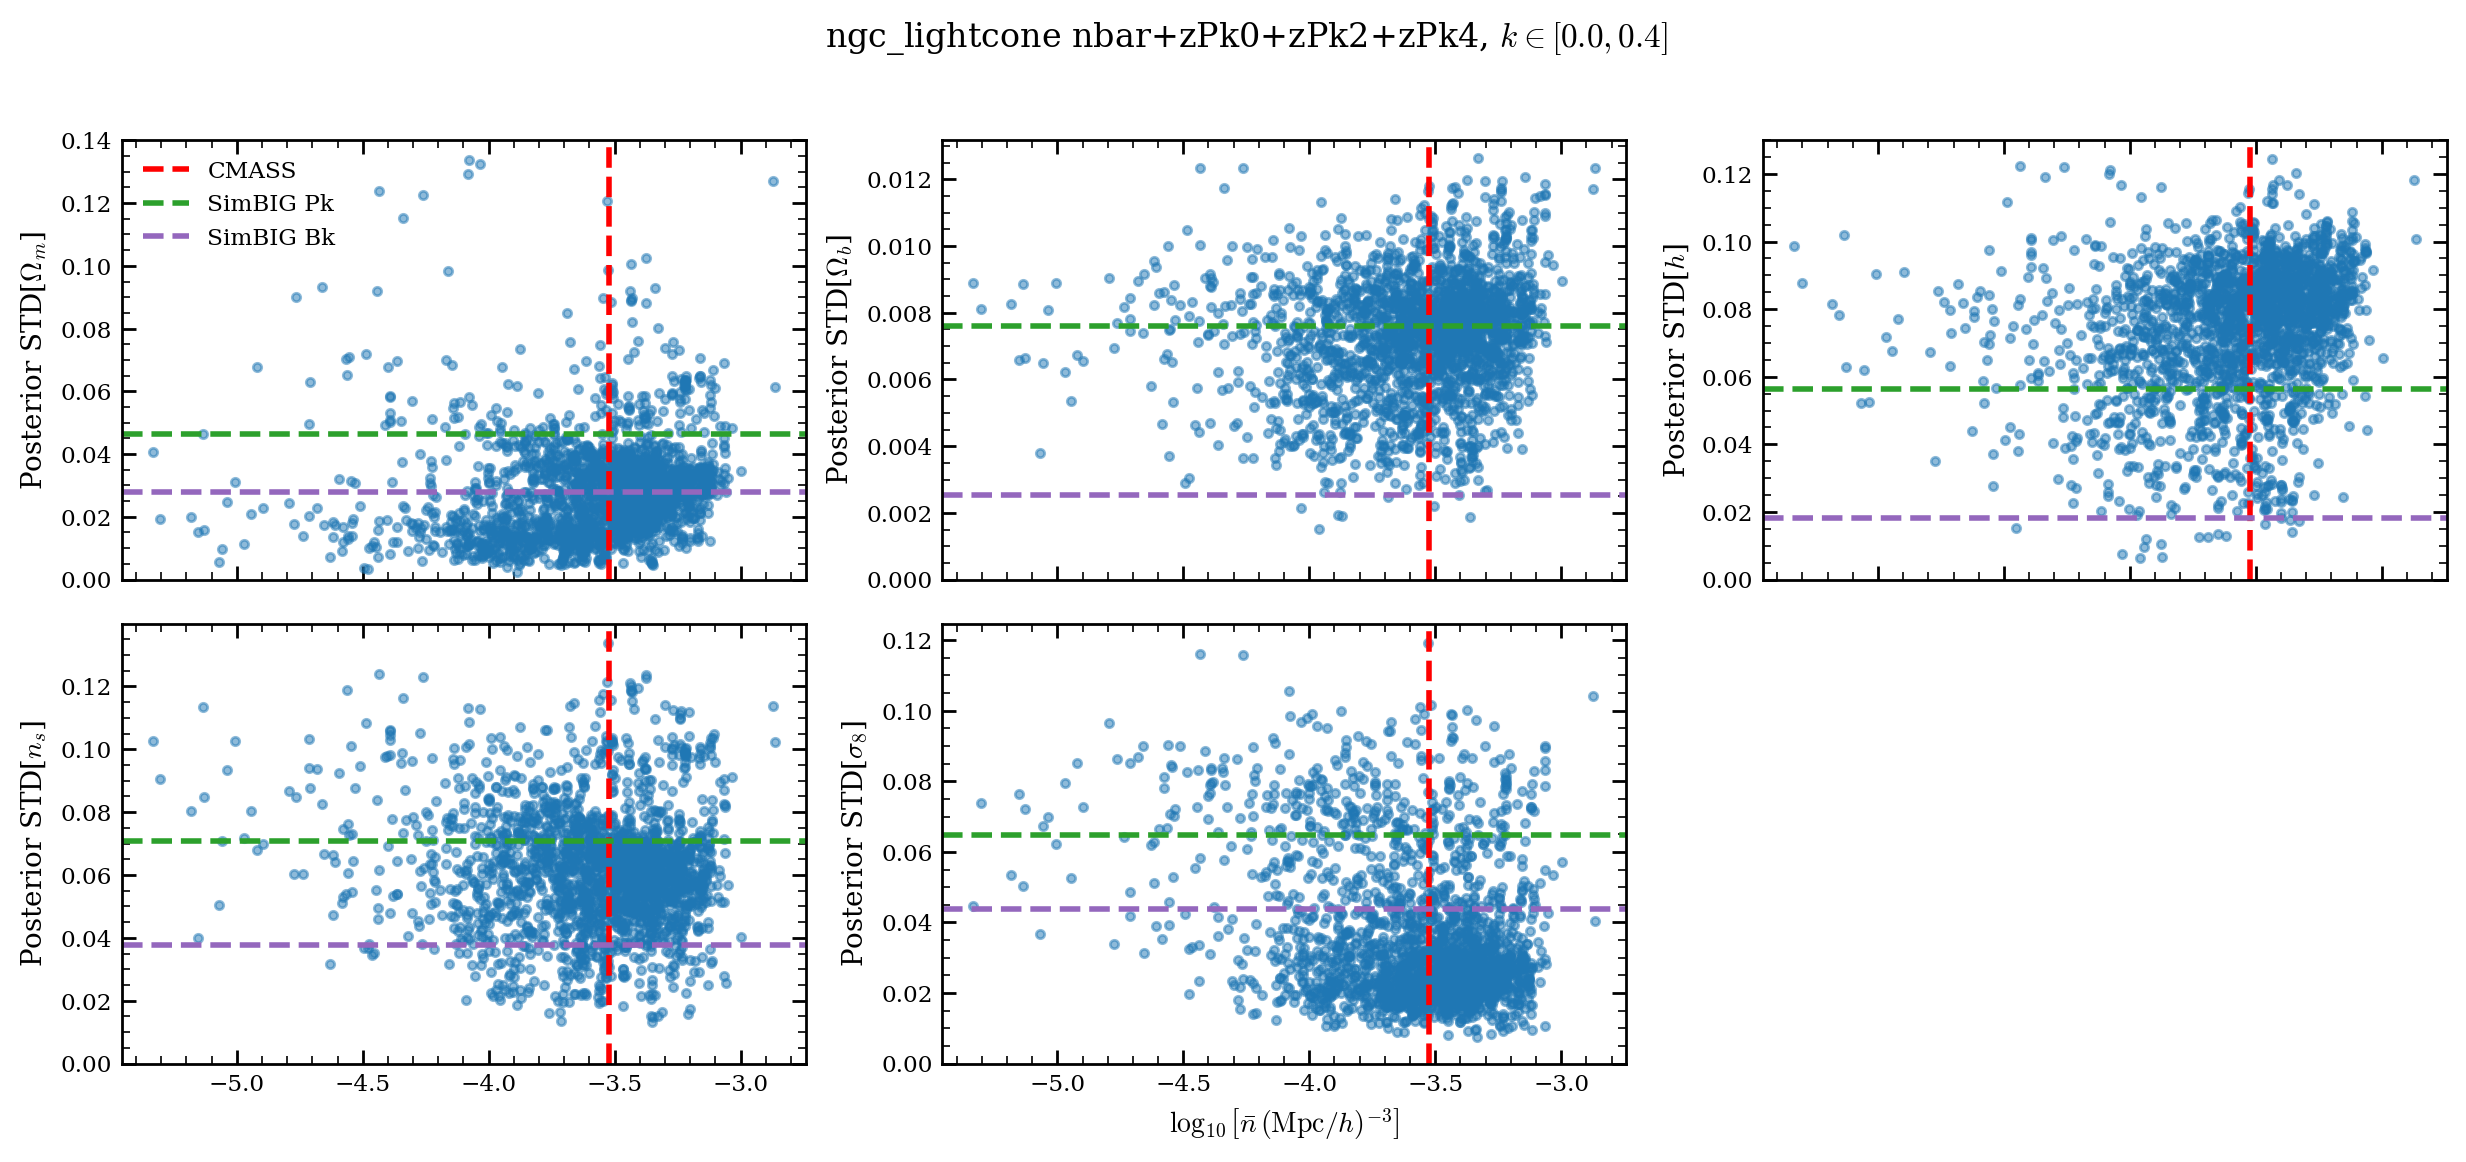

In [ ]:
if 'nbar' not in summaries:
    raise ValueError('Cell only works for nbar summary')

nbar_CMASS = np.log10(3e-4)
sb_pkstd = np.std(simpk.values[:, :-1].astype(float), axis=0)
sb_bkstd = np.std(simbk.values[:, :-1].astype(float), axis=0)

W = 3
H = len(names) // W + (len(names) % W > 0)

f, axs = plt.subplots(H, W, figsize=(5*W, 3*H),
                      sharex=True,
                      gridspec_kw=dict(hspace=0.1))
axs = axs.flatten()
for i, ax in enumerate(axs):
    if i >= len(names):
        ax.axis('off')
        continue
    lognbar = xtest[:, -1] + np.log10(boxvols[-1]/vols[-1])
    ax.plot(lognbar, samps.std(axis=0)[:, i], '.', alpha=0.5)
    ax.axvline(nbar_CMASS, color='r', ls='--', label='CMASS')
    ax.axhline(sb_pkstd[i], color='C2', ls='--', label='SimBIG Pk')
    ax.axhline(sb_bkstd[i], color='C4', ls='--', label='SimBIG Bk')
    ax.set_ylabel(f'Posterior STD[{names[i]}]')
    ax.set_ylim(0)
    if i == len(names) - 1:
        ax.set_xlabel(r'$\log_{10}\left[\bar{n}\, ({\rm Mpc}/h)^{-3}\right]$')
    if i == 0:
        ax.legend()

f.suptitle(
    f'{tracer} ' + '+'.join(summaries) + f', $k\in[{kmin},{kmax}]$')

Text(0.5, 0.98, 'ngc_lightcone nbar+zPk0+zPk2+zPk4, $k\\in[0.0,0.4]$')

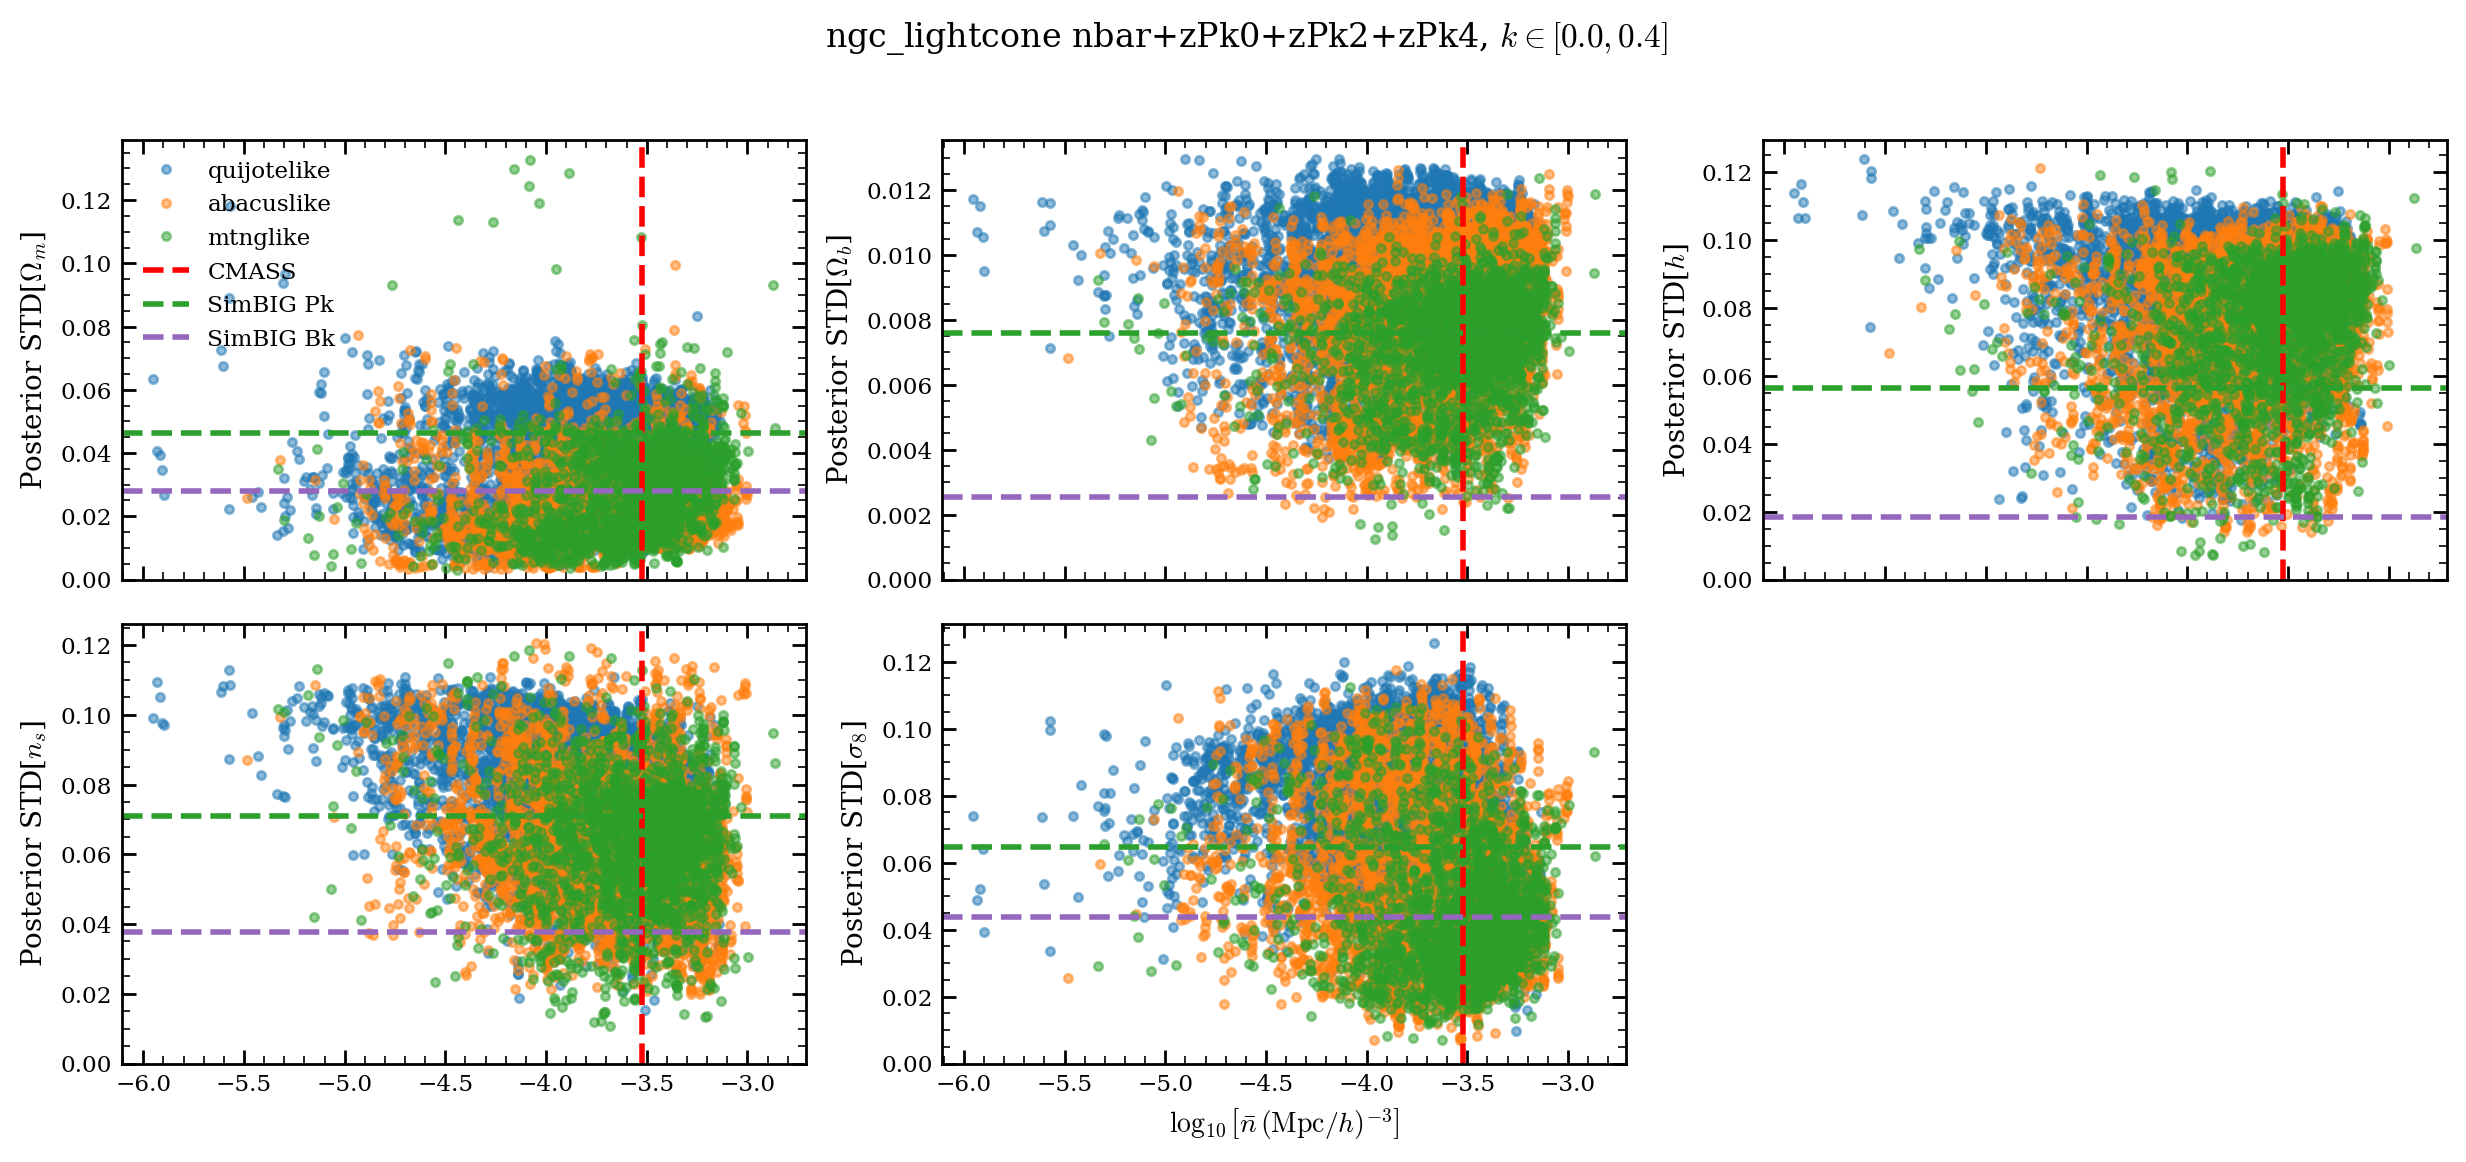

In [ ]:
if 'nbar' not in summaries:
    raise ValueError('Cell only works for nbar summary')

summary = summarylist[0]
xtests = xtestdict[summary]
sampss = sampsdict[summary]

nbar_CMASS = np.log10(3e-4)
sb_pkstd = np.std(simpk.values[:, :-1].astype(float), axis=0)
sb_bkstd = np.std(simbk.values[:, :-1].astype(float), axis=0)

W = 3
H = len(names) // W + (len(names) % W > 0)

f, axs = plt.subplots(H, W, figsize=(5*W, 3*H),
                      sharex=True,
                      gridspec_kw=dict(hspace=0.1))
axs = axs.flatten()
for i, ax in enumerate(axs):
    if i >= len(names):
        ax.axis('off')
        continue
    for j, n in enumerate(suites):
        xtest = xtests[j]
        samps = sampss[j]
        lognbar = xtest[:, -1] + np.log10(boxvols[j]/vols[j])
        ax.plot(lognbar, samps.std(axis=0)[:, i], '.', alpha=0.5, label=n)
    ax.axvline(nbar_CMASS, color='r', ls='--', label='CMASS')
    ax.axhline(sb_pkstd[i], color='C2', ls='--', label='SimBIG Pk')
    ax.axhline(sb_bkstd[i], color='C4', ls='--', label='SimBIG Bk')
    ax.set_ylabel(f'Posterior STD[{names[i]}]')
    ax.set_ylim(0)
    if i == len(names) - 1:
        ax.set_xlabel(r'$\log_{10}\left[\bar{n}\, ({\rm Mpc}/h)^{-3}\right]$')
    if i == 0:
        ax.legend()

f.suptitle(
    f'{tracer} ' + '+'.join(summaries) + f', $k\in[{kmin},{kmax}]$')

nbar+Pk0


Text(0.5, 0.98, 'ngc_lightcone nbar+zPk0+zPk2+zPk4, $k\\in[0.0,0.4]$, $\\bar{n} \\sim \\bar{n}_{\\rm CMASS}$')

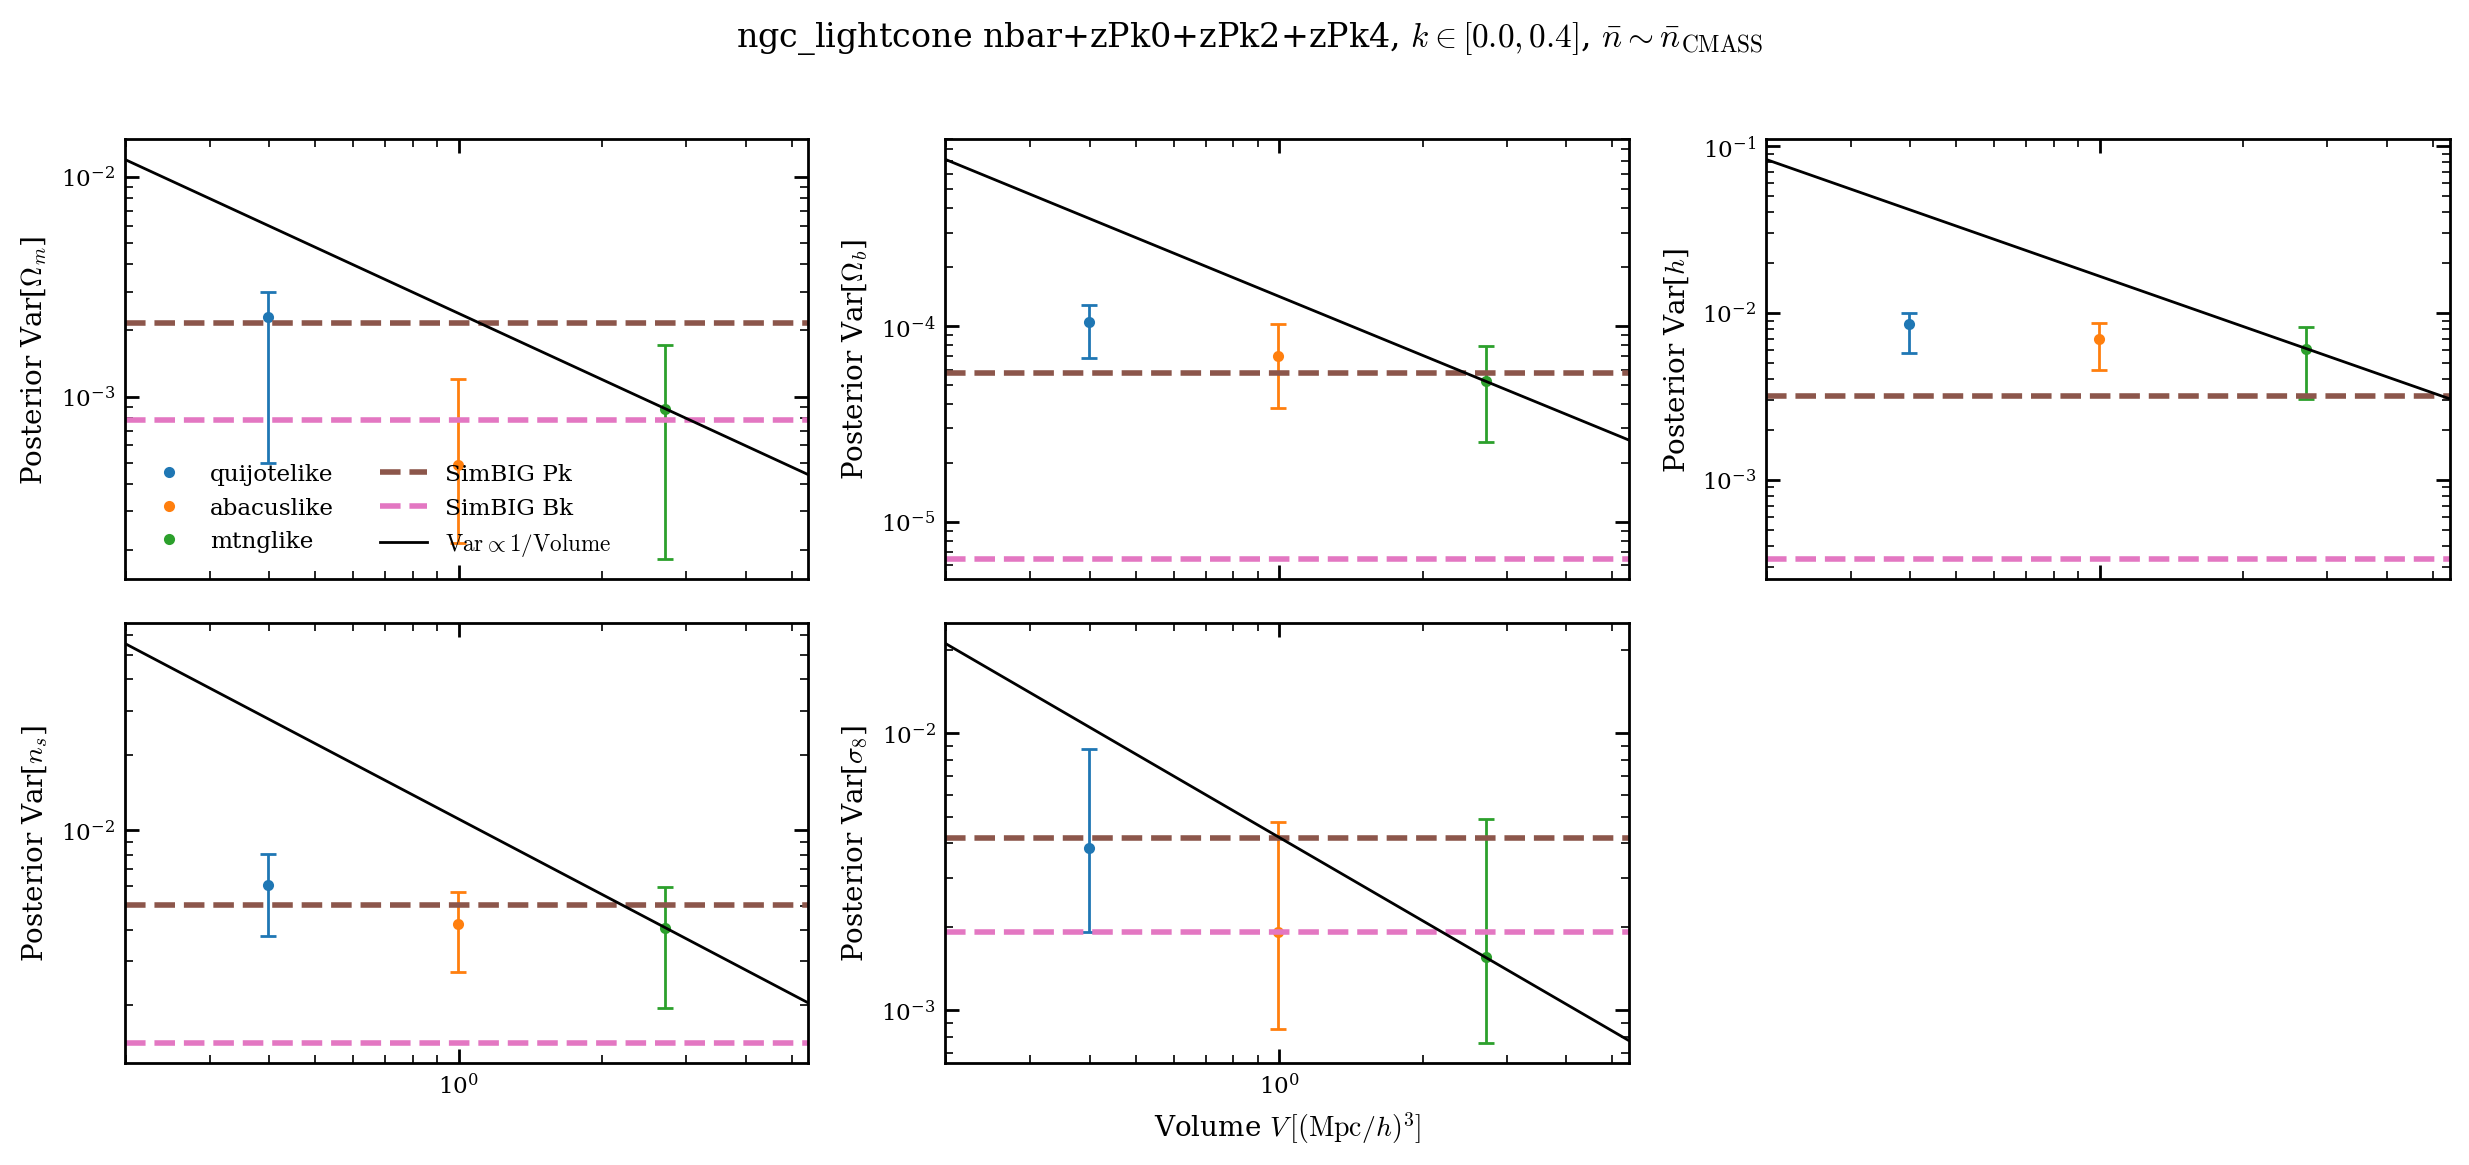

In [ ]:
if 'nbar' not in summaries:
    raise ValueError('Cell only works for nbar summary')

summary = summarylist[0]
print(summary)
xtests = xtestdict[summary]
sampss = sampsdict[summary]

# Constants
nbar_CMASS = np.log10(3e-4)
dnbar = 0.05
W, H = 3, len(names) // 3 + (len(names) % 3 > 0)

# Compute standard deviations
sb_pkstd = np.std(simpk.values[:, :-1].astype(float), axis=0)
sb_bkstd = np.std(simbk.values[:, :-1].astype(float), axis=0)

# Create subplots
f, axs = plt.subplots(H, W, figsize=(5 * W, 3 * H),
                      sharex=True, gridspec_kw=dict(hspace=0.1))
axs = axs.flatten()

# Iterate over parameters
for i, ax in enumerate(axs):
    if i >= len(names):
        ax.axis('off')
        continue

    # Plot data for each suite
    for j, suite in enumerate(suites):
        xtest = xtests[j]
        samps = sampss[j]
        lognbar = xtest[:, -1] + np.log10(boxvols[j]/vols[j])
        mask = (lognbar > nbar_CMASS -
                dnbar) & (lognbar < nbar_CMASS + dnbar)
        p = np.percentile(samps[:, mask, i].var(axis=0), [16, 50, 84], axis=0)

        # Plot median and error bars
        ax.plot(vols[j], p[1], '.', label=suite, c=f'C{j}')
        yerr = np.array([[p[1] - p[0], p[2] - p[1]]]).T
        ax.errorbar(vols[j], p[1], yerr=yerr, fmt='none',
                    ecolor=f'C{j}', elinewidth=1, capsize=3, capthick=1)

    # Plot reference lines
    ax.axhline(sb_pkstd[i]**2, color='C5', ls='--', label='SimBIG Pk')
    ax.axhline(sb_bkstd[i]**2, color='C6', ls='--', label='SimBIG Bk')

    # Plot normalization curve
    norm_factor = p[1] / (1 / vols[j])
    _v = np.linspace(vols.min() / 2, vols.max() * 2, 100)
    ax.plot(_v, (1 / _v) * norm_factor, 'k-', lw=1,
            label=r'${\rm Var} \propto 1/{\rm Volume}$')

    # Set axis properties
    ax.loglog()
    ax.set_xlim(_v.min(), _v.max())
    ax.set_ylabel(f'Posterior Var[{names[i]}]')
    if i == len(names) - 1:
        ax.set_xlabel(r'Volume $V\,[({\rm Mpc}/h)^3]$')
    if i == 0:
        ax.legend(ncol=2, loc='lower left')

# Set title
f.suptitle(f'{tracer} ' + '+'.join(summaries) +
           f', $k\\in[{kmin},{kmax}]$, ' + r'$\bar{n} \sim \bar{n}_{\rm CMASS}$')

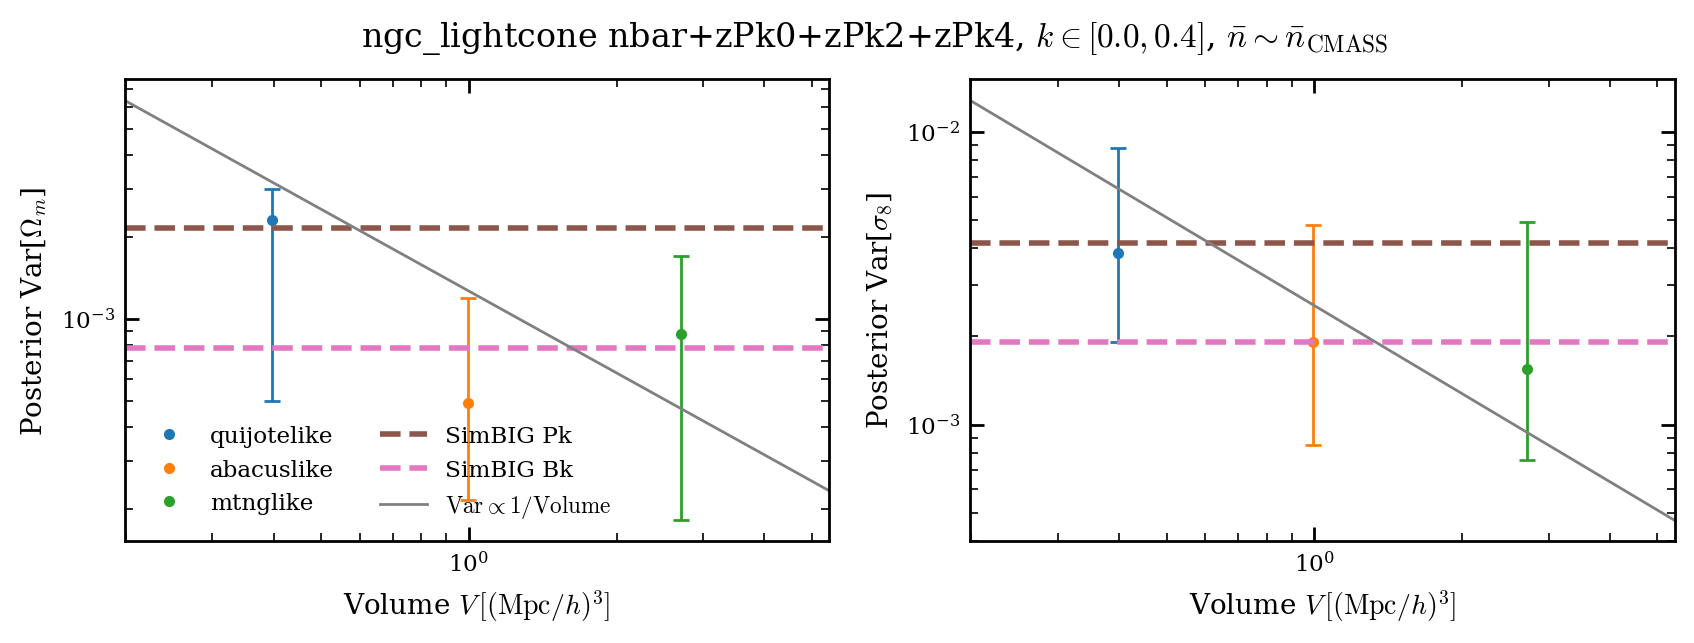

In [ ]:
if 'nbar' not in summaries:
    raise ValueError('Cell only works for nbar summary')

summary = summarylist[0]
xtests = xtestdict[summary]
sampss = sampsdict[summary]

# Constants
nbar_CMASS = np.log10(3e-4)
dnbar = 0.05
W, H = 2, 1

# Compute standard deviations
sb_pkstd = np.std(simpk.values[:, :-1].astype(float), axis=0)
sb_bkstd = np.std(simbk.values[:, :-1].astype(float), axis=0)

# Create subplots
f, axs = plt.subplots(H, W, figsize=(5 * W, 3 * H),
                      sharex=True, gridspec_kw=dict(hspace=0.1))
axs = axs.flatten()

# Iterate over parameters
for k, i in enumerate([0, 4]):  # Only plot Omega_m and sigma_8
    ax = axs[k]
    if i >= len(names):
        ax.axis('off')
        continue

    # Store all points for the 1/V fit
    all_volumes = []
    all_variances = []

    # Plot data for each suite
    for j, suite in enumerate(suites):
        xtest = xtests[j]
        samps = sampss[j]
        lognbar = xtest[:, -1] + np.log10(boxvols[j]/vols[j])
        mask = (lognbar > nbar_CMASS -
                dnbar) & (lognbar < nbar_CMASS + dnbar)
        p = np.percentile(samps[:, mask, i].var(axis=0), [16, 50, 84], axis=0)

        volume = vols[j]
        variance = p[1]

        # Plot median and error bars
        ax.plot(volume, variance, '.', label=suite, c=f'C{j}')
        yerr = np.array([[variance - p[0], p[2] - variance]]).T
        ax.errorbar(volume, variance, yerr=yerr, fmt='none',
                    ecolor=f'C{j}', elinewidth=1, capsize=3, capthick=1)

        # Append data for the fit
        all_volumes.append(volume)
        all_variances.append(variance)

    # Plot reference lines
    ax.axhline(sb_pkstd[i]**2, color='C5', ls='--', label='SimBIG Pk')
    ax.axhline(sb_bkstd[i]**2, color='C6', ls='--', label='SimBIG Bk')

    # Calculate the normalization factor from all points
    norm_factor = np.mean(np.array(all_variances) * np.array(all_volumes))
    _v = np.linspace(vols.min() / 2, vols.max() * 2, 100)
    ax.plot(_v, norm_factor / _v, '-', c='gray', lw=1,
            label=r'${\rm Var} \propto 1/{\rm Volume}$')

    # Set axis properties
    ax.loglog()
    ax.set_xlim(_v.min(), _v.max())
    ax.set_ylabel(f'Posterior Var[{names[i]}]')
    ax.set_xlabel(r'Volume $V\,[({\rm Mpc}/h)^3]$')
    if i == 0:
        ax.legend(ncol=2, loc='lower left')

# Set title
f.suptitle(f'{tracer} ' + '+'.join(summaries) +
           f', $k\\in[{kmin},{kmax}]$, ' + r'$\bar{n} \sim \bar{n}_{\rm CMASS}$')
plt.show()

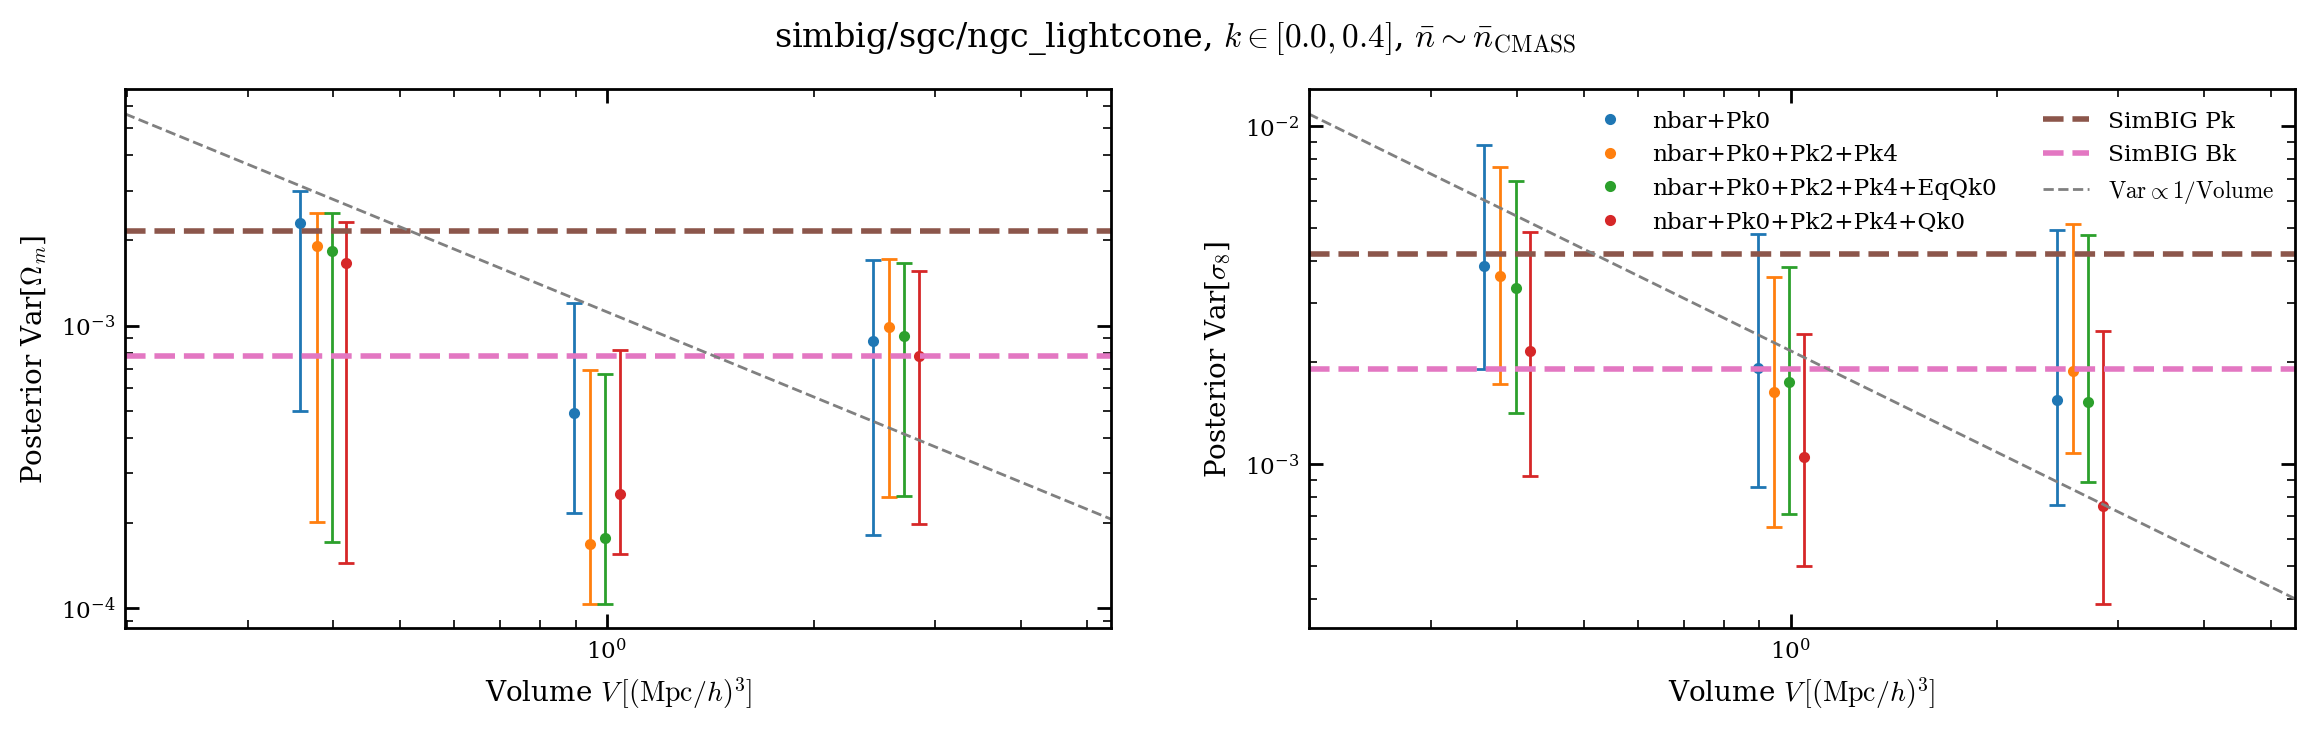

In [ ]:
if 'nbar' not in summaries:
    raise ValueError('Cell only works for nbar summary')

# Constants
nbar_CMASS = np.log10(3e-4)
dnbar = 0.05
W, H = 2, 1

# Compute standard deviations
sb_pkstd = np.std(simpk.values[:, :-1].astype(float), axis=0)
sb_bkstd = np.std(simbk.values[:, :-1].astype(float), axis=0)

# Create subplots
f, axs = plt.subplots(H, W, figsize=(7 * W, 3.5 * H),
                      sharex=True, gridspec_kw=dict(hspace=0.1))
axs = axs.flatten()

# Iterate over parameters
for k, i in enumerate([0, 4]):  # Only plot Omega_m and sigma_8

    ax = axs[k]
    if i >= len(names):
        ax.axis('off')
        continue

    # Store all points for the 1/V fit
    all_volumes = []
    all_variances = []

    # Iterate over summaries
    for l, summary in enumerate(summarylist):
        xtests = xtestdict[summary]
        sampss = sampsdict[summary]
        # Plot data for each suite
        for j, suite in enumerate(suites):
            xtest = xtests[j]
            samps = sampss[j]

            lognbar = xtest[:, -1] + np.log10(boxvols[j]/vols[j])
            mask = (lognbar > nbar_CMASS -
                    dnbar) & (lognbar < nbar_CMASS + dnbar)
            p = np.percentile(samps[:, mask, i].var(
                axis=0), [16, 50, 84], axis=0)

            # Plot median and error bars
            offset = (1 + l/20 - len(summarylist)/20/2)
            volume = vols[j] * offset
            variance = p[1]
            ax.plot(volume, variance, '.', c=f'C{l}',
                    label=summary if j == 0 else None)
            yerr = np.array([[variance - p[0], p[2] - variance]]).T
            ax.errorbar(volume, variance, yerr=yerr, fmt='none',
                        ecolor=f'C{l}', elinewidth=1, capsize=3, capthick=1)

            # Append data for the fit
            all_volumes.append(volume)
            all_variances.append(variance)

    # Plot reference lines
    ax.axhline(sb_pkstd[i]**2, color='C5', ls='--', label='SimBIG Pk')
    ax.axhline(sb_bkstd[i]**2, color='C6', ls='--', label='SimBIG Bk')

    # Calculate the normalization factor from all points
    norm_factor = np.mean(np.array(all_variances) * np.array(all_volumes))
    _v = np.linspace(vols.min() / 2, vols.max() * 2, 100)
    ax.plot(_v, norm_factor / _v, '--', c='gray', lw=1,
            label=r'${\rm Var} \propto 1/{\rm Volume}$')

    # Set axis properties
    ax.loglog()
    ax.set_xlim(_v.min(), _v.max())
    ax.set_ylabel(f'Posterior Var[{names[i]}]')
    ax.set_xlabel(r'Volume $V\,[({\rm Mpc}/h)^3]$')

axs[1].legend(ncol=2)

# Set title
f.suptitle(f'simbig/sgc/ngc_lightcone' +
           f', $k\\in[{kmin},{kmax}]$, ' + r'$\bar{n} \sim \bar{n}_{\rm CMASS}$')

plt.show()

## Copy of old plot

In [ ]:
temp_df = pd.read_csv('tempsigma8.csv', skipinitialspace=True)
N = len(temp_df)

med = temp_df[::3]
low = temp_df[1::3]
high = temp_df[2::3]
med, low, high = map(np.sqrt, [med, low, high])

data = {}
names = ['pk0', 'pk024', 'eq0', 'q0']
names = [r'$P_0(k<0.4)$', r'$P_{\ell=0,2,4}(k<0.4)$', r'$P_\ell(k<0.4)+Q_0(k_{\rm eq}<0.4)$',
         r'$P_\ell(k<0.4)+Q_0(k<0.4)$']
# names = ['$P(k)$ monopole', '$P(k)$ all' ]
names = ['LtU ' + x for x in names]
names = np.array(names)
n = len(names)
vols = np.array([1, 2, 3])**3  # for boxes
for i, name in enumerate(names):
    data[name] = (
        med[i::4],
        low[i::4],
        high[i::4]
    )
names = names[[0, 1, 3]]

# Compute standard deviations
sb_pkstd = np.std(simpk.values[:, :-1].astype(float), axis=0)
sb_bkstd = np.std(simbk.values[:, :-1].astype(float), axis=0)

(0.01, 0.13)

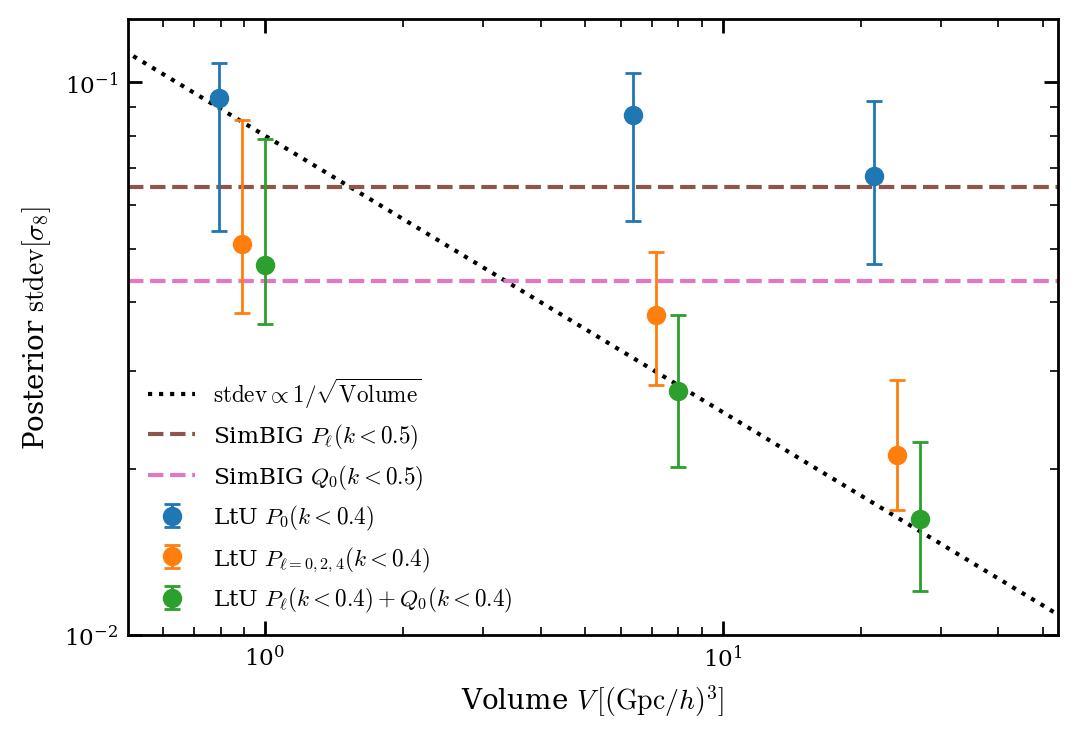

In [16]:
f, ax = plt.subplots(figsize=(6, 4))
ax.loglog()

_x = np.linspace(vols[0]*10**(-1), vols[-1]*10**(1), 100)
_y = (8e-2 / np.sqrt(_x))
ax.plot(_x, _y, 'k:', lw=1.5,
        label=r'${\rm stdev} \propto 1/\sqrt{\rm Volume}$')

ax.axhline(sb_pkstd[4], color='C5', ls='--',
           lw=1.5, label='SimBIG $P_\ell(k<0.5)$')
ax.axhline(sb_bkstd[4], color='C6', ls='--',
           lw=1.5, label='SimBIG $Q_0(k<0.5)$')

dv = 0.05
for i, name in enumerate(names):
    med, low, high = data[name]
    ax.errorbar(vols*10**(i*dv - n*dv/2),
                med['y'], yerr=[med['y'] - low['y'].values,
                                high['y'].values - med['y']],
                fmt='o', elinewidth=1, capsize=3, capthick=1,
                label=name)
ax.set_xlabel(r'Volume $V\,[({\rm Gpc}/h)^3]$')
ax.set_ylabel(r'Posterior ${\rm stdev}[\sigma_8]$')
ax.legend(ncol=1)
dv = 0.3
ax.set_xlim(vols[0]*10**(-dv), vols[-1]*10**(dv))
ax.set_ylim(1e-2, 1.3e-1)

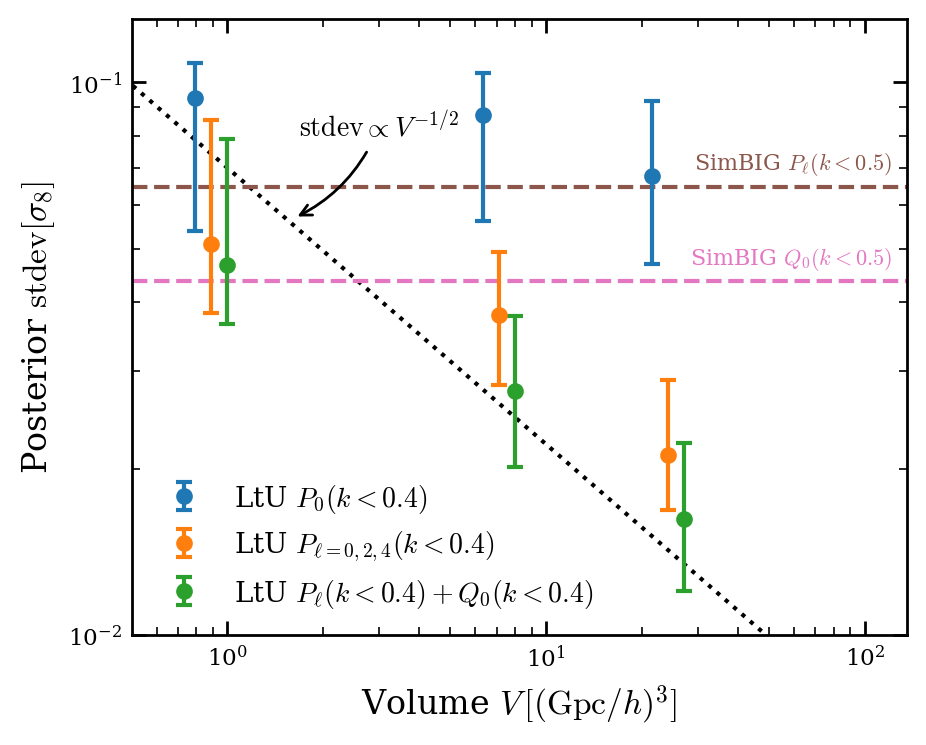

In [71]:
f, ax = plt.subplots(figsize=(5, 4))
ax.loglog()

_x = np.linspace(vols[0]*10**(-1), vols[-1]*10**(1), 100)
_y = (7e-2 / np.sqrt(_x))
# Plot lines without adding them to the legend
ax.plot(_x, _y, 'k:', lw=1.5, ls=':')
ax.axhline(sb_pkstd[4], color='C5', ls='--', lw=1.5)
ax.axhline(sb_bkstd[4], color='C6', ls='--', lw=1.5)


dv = 0.05
for i, name in enumerate(names):
    med, low, high = data[name]
    ax.errorbar(vols*10**(i*dv - n*dv/2),
                med['y'], yerr=[med['y'] - low['y'].values,
                                high['y'].values - med['y']],
                fmt='o', elinewidth=1.5, capsize=3, capthick=1.5, markersize=5,
                label=name, zorder=10)

ax.set_xlabel(r'Volume $V\,[({\rm Gpc}/h)^3]$', fontsize=12)
ax.set_ylabel(r'Posterior ${\rm stdev}[\sigma_8]$', fontsize=12)
dv = 0.4
ax.set_xlim(vols[0]*10**(-0.3), vols[-1]*10**(0.7))
ax.set_ylim(1e-2, 1.3e-1)

# --- Add labels directly onto the plot ---
p1 = ax.transData.transform_point((_x[20], _y[20]))
p2 = ax.transData.transform_point((_x[80], _y[80]))
angle = np.degrees(np.arctan2(p2[1] - p1[1], p2[0] - p1[0]))
ax.annotate(r'${\rm stdev} \propto V^{-1/2}$',  # Your text label
            # Point the arrow is pointing to (on the line)
            xy=(1.6, 8e-2 / np.sqrt(2)),
            xytext=(3., 0.08),                       # Where the text is located
            arrowprops=dict(arrowstyle="->",      # Arrow style
                            connectionstyle="arc3,rad=-0.2",  # Curve of the arrow
                            color='black'),
            ha='center')

xlim_max = ax.get_xlim()[1]*0.9  # Get the final x-limit for positioning
ax.text(xlim_max, sb_pkstd[4]*1.1, ' SimBIG $P_\ell(k<0.5)$', fontsize=8,
        color='C5', ha='right', va='center')
ax.text(xlim_max, sb_bkstd[4]*1.1, ' SimBIG $Q_0(k<0.5)$', fontsize=8,
        color='C6', ha='right', va='center')

# The legend will now correctly show only the labels from the errorbar plots
ax.legend(ncol=1, fontsize=10)
# ax.set_title(
#     r'$k_{\rm max} = 0.4\ h/{\rm Mpc}$, $\bar{n} \sim \bar{n}_{\rm CMASS}$',)

In [73]:
temp_df = pd.read_csv('tempOmegaM.csv', skipinitialspace=True)
N = len(temp_df)

med = temp_df[::3]
low = temp_df[1::3]
high = temp_df[2::3]
med, low, high = map(np.sqrt, [med, low, high])

data = {}
names = ['pk0', 'pk024', 'eq0', 'q0']
names = [r'$P_0(k<0.4)$', r'$P_{\ell=0,2,4}(k<0.4)$', r'$P_\ell(k<0.4)+Q_0(k_{\rm eq}<0.4)$',
         r'$P_\ell(k<0.4)+Q_0(k<0.4)$']
# names = ['$P(k)$ monopole', '$P(k)$ all' ]
names = ['LtU ' + x for x in names]
names = np.array(names)
n = len(names)
vols = np.array([1, 2, 3])**3  # for boxes
for i, name in enumerate(names):
    data[name] = (
        med[i::4],
        low[i::4],
        high[i::4]
    )
names = names[[0, 1, 3]]

# Compute standard deviations
sb_pkstd = np.std(simpk.values[:, :-1].astype(float), axis=0)
sb_bkstd = np.std(simbk.values[:, :-1].astype(float), axis=0)

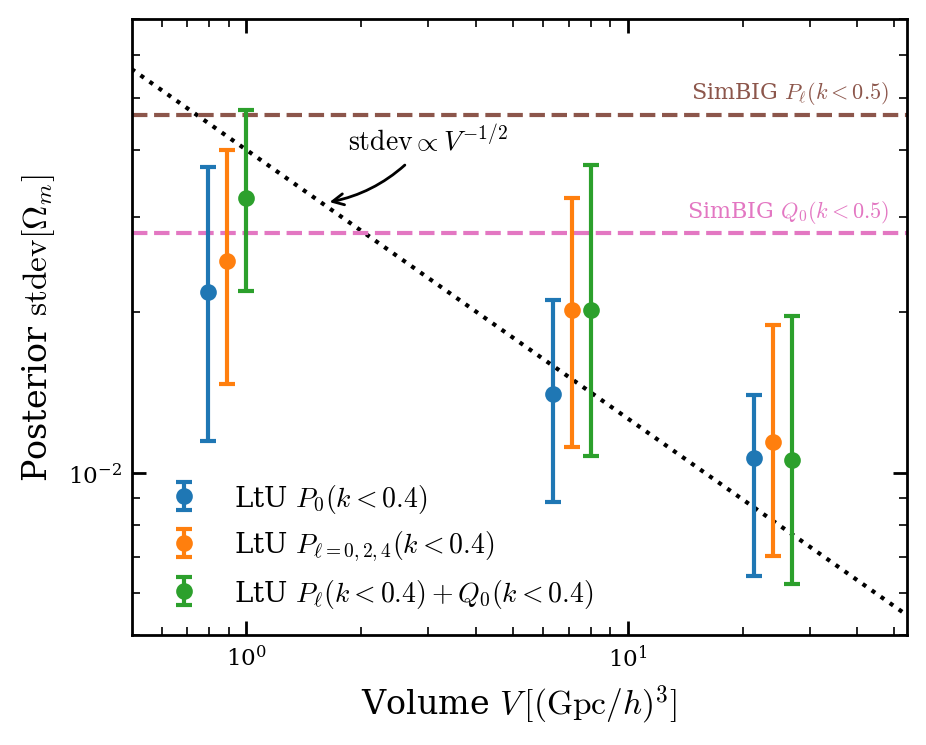

In [90]:
f, ax = plt.subplots(figsize=(5, 4))
ax.loglog()

_x = np.linspace(vols[0]*10**(-1), vols[-1]*10**(1), 100)
_y = (4e-2 / np.sqrt(_x))
# Plot lines without adding them to the legend
ax.plot(_x, _y, 'k:', lw=1.5, ls=':')
ax.axhline(sb_pkstd[0], color='C5', ls='--', lw=1.5)
ax.axhline(sb_bkstd[0], color='C6', ls='--', lw=1.5)


dv = 0.05
for i, name in enumerate(names):
    med, low, high = data[name]
    ax.errorbar(vols*10**(i*dv - n*dv/2),
                med['y'], yerr=[med['y'] - low['y'].values,
                                high['y'].values - med['y']],
                fmt='o', elinewidth=1.5, capsize=3, capthick=1.5, markersize=5,
                label=name, zorder=10)

ax.set_xlabel(r'Volume $V\,[({\rm Gpc}/h)^3]$', fontsize=12)
ax.set_ylabel(r'Posterior ${\rm stdev}[\Omega_m]$', fontsize=12)
dv = 0.4
ax.set_xlim(vols[0]*10**(-0.3), vols[-1]*10**(0.3))
ax.set_ylim(5e-3, 7e-2)

# --- Add labels directly onto the plot ---
p1 = ax.transData.transform_point((_x[20], _y[20]))
p2 = ax.transData.transform_point((_x[80], _y[80]))
angle = np.degrees(np.arctan2(p2[1] - p1[1], p2[0] - p1[0]))
ax.annotate(r'${\rm stdev} \propto V^{-1/2}$',  # Your text label
            # Point the arrow is pointing to (on the line)
            xy=(1.6, 4.5e-2 / np.sqrt(2)),
            xytext=(3., 0.04),                       # Where the text is located
            arrowprops=dict(arrowstyle="->",      # Arrow style
                            connectionstyle="arc3,rad=-0.2",  # Curve of the arrow
                            color='black'),
            ha='center')

xlim_max = ax.get_xlim()[1]*0.9  # Get the final x-limit for positioning
ax.text(xlim_max, sb_pkstd[0]*1.1, ' SimBIG $P_\ell(k<0.5)$', fontsize=8,
        color='C5', ha='right', va='center')
ax.text(xlim_max, sb_bkstd[0]*1.1, ' SimBIG $Q_0(k<0.5)$', fontsize=8,
        color='C6', ha='right', va='center')

# The legend will now correctly show only the labels from the errorbar plots
ax.legend(ncol=1, fontsize=10)
# ax.set_title(
#     r'$k_{\rm max} = 0.4\ h/{\rm Mpc}$, $\bar{n} \sim \bar{n}_{\rm CMASS}$',)

## Compute approximate volumes of each lightcone footprint

## Find good n(z)

In [ ]:
nz_obs = np.loadtxt(
    '/anvil/scratch/x-mho1/cmass-ili/obs/n-z/nz_DR12v5_CMASS_North_zmin0.4000_zmax0.7000.dat')
nz_obs_bin = np.linspace(0.4, 0.7, len(nz_obs)+1)
nz_obs_cen = 0.5*(nz_obs_bin[1:] + nz_obs_bin[:-1])

(0.0, 20000.0)

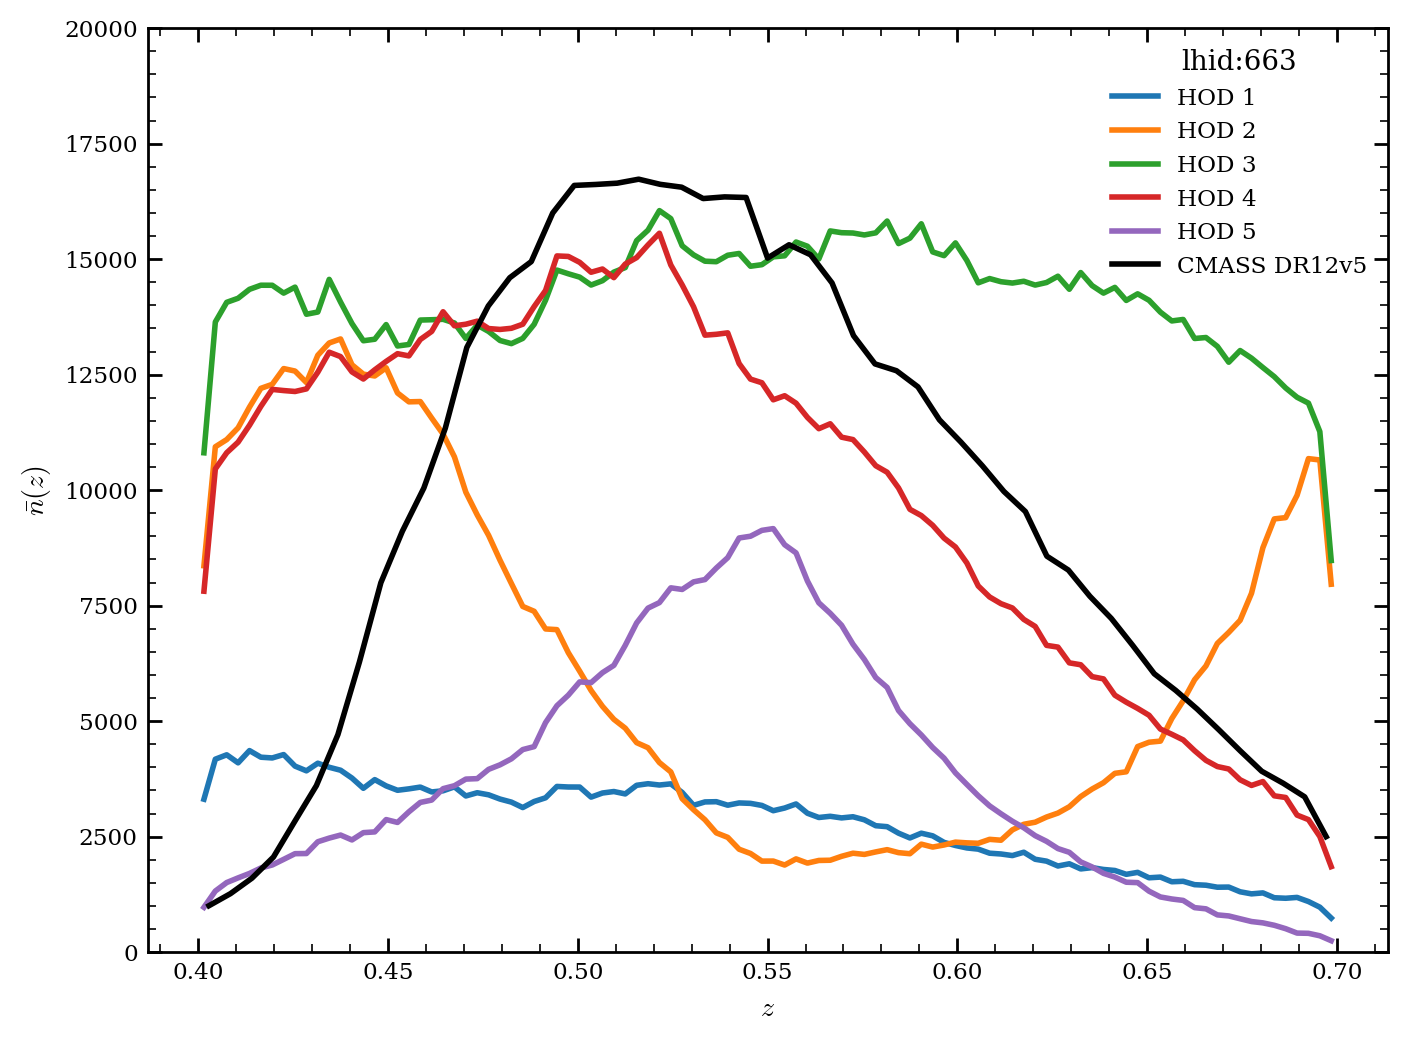

In [23]:
import h5py
plt.figure(figsize=(8, 6))

for i in range(1, 6):
    file_path = f'/anvil/scratch/x-mho1/cmass-ili/mtnglike/fastpm_recnoise/L3000-N384/663/diag/ngc_lightcone/hod0663{i}_aug00000.h5'

    with h5py.File(file_path, 'r') as f:
        nz = f['nz'][:]
        be = f['nz_bins'][:]

    bc = 0.5 * (be[:-1] + be[1:])
    plt.plot(bc, nz, '-', lw=2, label=f'HOD {i}')
plt.plot(nz_obs_cen, nz_obs, 'k-', lw=2, label='CMASS DR12v5')
plt.xlabel(r'$z$')
plt.ylabel(r'$\bar{n}(z)$')
plt.legend(title='lhid:663')
plt.ylim(0, 20000)